<a href="https://colab.research.google.com/github/LuRSousa/FIAP-SERS_2026/blob/main/aula09-machine_learning/regressao_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exercício de Machine Learning

Treinar um modelo de regressão linear para prever os valores
da coluna 'stab'.
sklearn ----> LinearRegression

Fonte:

##Preparação do Ambiente



In [69]:
#Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

#Machine Learning
#Algotimo do sklearn para regressão linear
from sklearn.linear_model import LinearRegression

#Separação de dados de treino e teste
from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test

#Métricas de regressão
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

##Carregar os Dados

In [70]:
dados = pd.read_csv("https://raw.githubusercontent.com/LuRSousa/FIAP-SERS_2026/refs/heads/main/aula08-machine_learning/Data_for_UCI_named.csv")

dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


##Análise Exploratória

In [71]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [72]:
#Somente estatísticas de atributos categóricos
dados.describe(include="object")

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [73]:
#Somente estatísticas de atributos numéricos
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [74]:
#Instanciando o modelo_LR com base na classe LinearRegression
modelo_LR = LinearRegression()

In [75]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


## Análise de Correlação para Regressão Linear

Vamos gerar uma matriz de correlação para identificar as features com maior correlação linear com a variável alvo `stab`.

Correlação das features com 'stab':
 stab    1.000000
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
g4      0.279214
tau4    0.278576
tau1    0.275761
p1      0.010278
p2      0.006255
p3     -0.003321
p4     -0.020786
Name: stab, dtype: float64


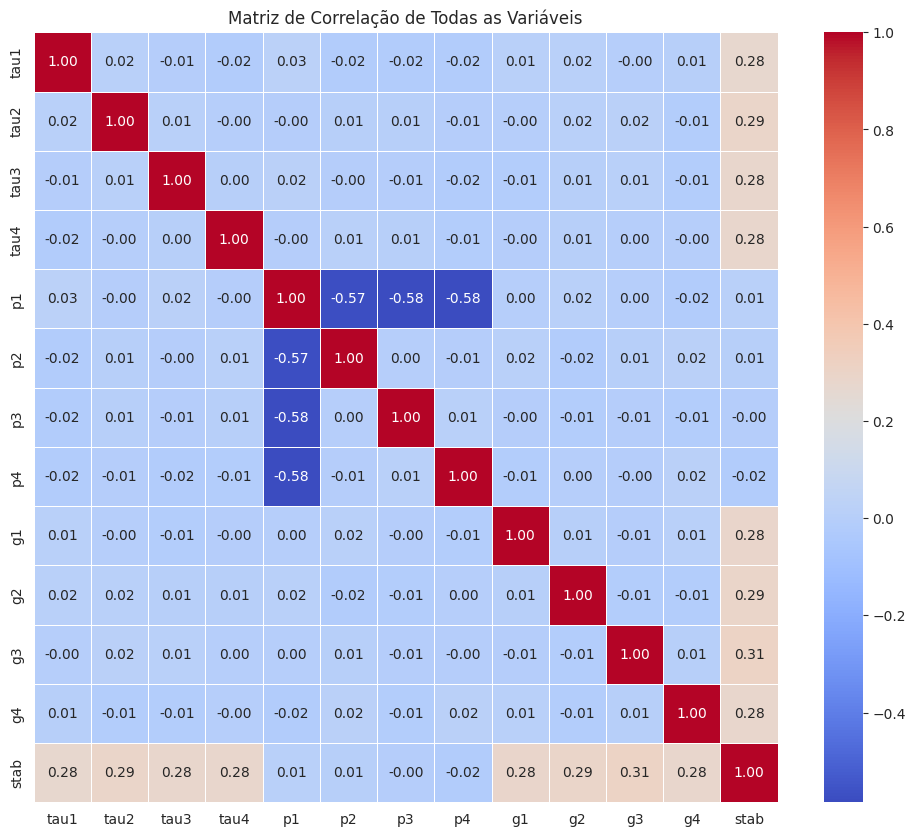

In [76]:
# Parte do gemini (selecionando os 3 atributos)
# Calculate the correlation matrix
correlation_matrix = dados.corr(numeric_only=True)

# Get correlations with the 'stab' column
stab_correlations = correlation_matrix['stab'].sort_values(ascending=False)

print("Correlação das features com 'stab':\n", stab_correlations)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação de Todas as Variáveis')
plt.show()

### Gráficos de Dispersão com Linhas de Regressão (Fundo Preto)

Vamos aprofundar a visualização da relação entre as três features mais correlacionadas e a variável alvo `stab`, incluindo as linhas de regressão e utilizando um fundo preto para os gráficos.

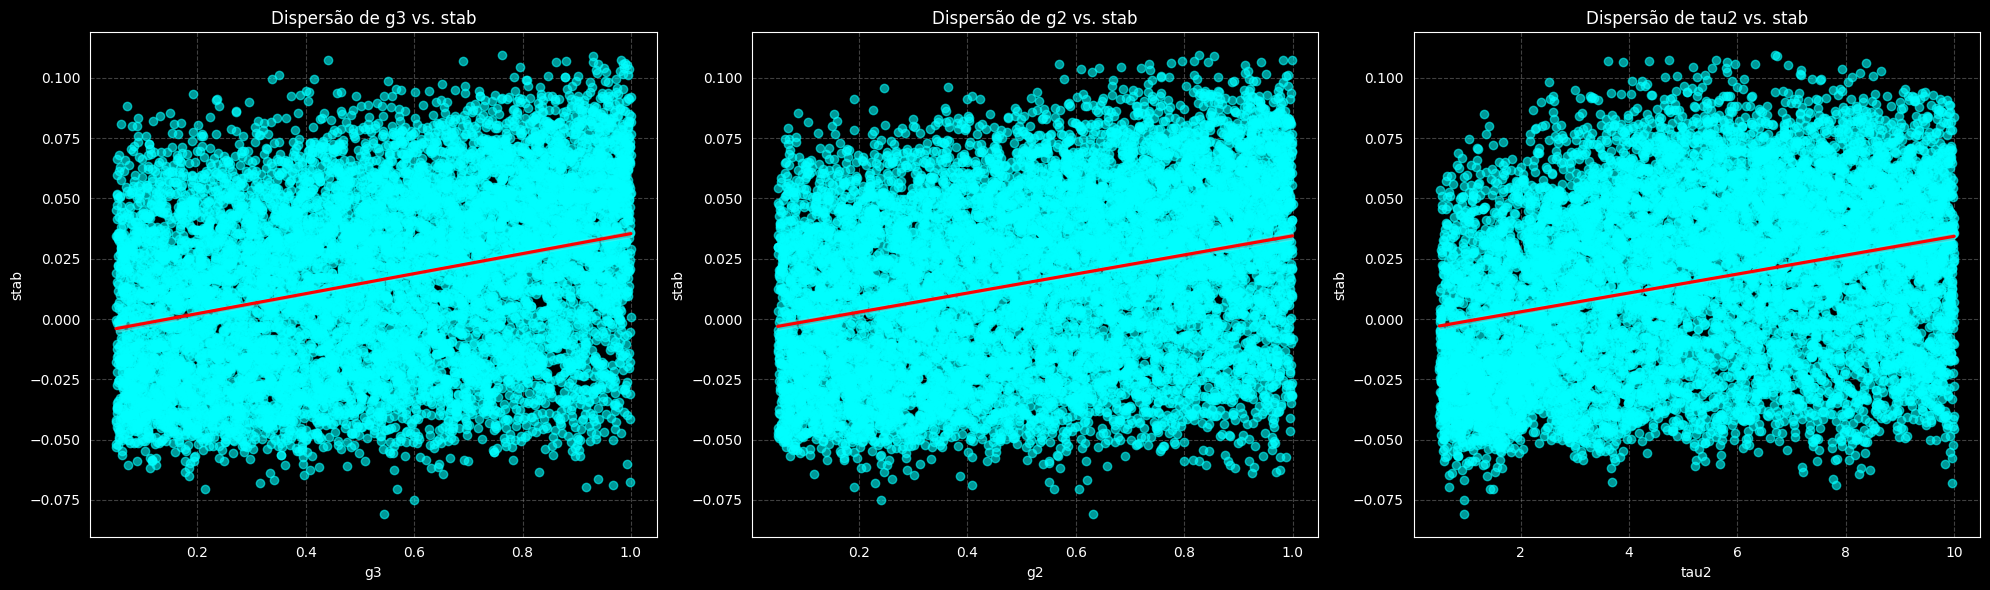

In [77]:
# Features with highest correlation to 'stab' (from previous step)
# Based on 'stab_correlations' variable: 'g3', 'g2', 'tau2'
top_correlated_features = ['g3', 'g2', 'tau2']

# Set the aesthetic style of the plots
sb.set_style("darkgrid", {"axes.facecolor": "black", "figure.facecolor": "black"})

plt.figure(figsize=(20, 6)) # Adjust figure size for three subplots

for i, feature in enumerate(top_correlated_features):
    plt.subplot(1, 3, i + 1) # Create subplots (1 row, 3 columns)
    sb.regplot(x=dados[feature], y=dados['stab'], scatter_kws={'alpha':0.6, 'color':'cyan'}, line_kws={'color':'red'})
    plt.title(f'Dispersão de {feature} vs. stab', color='white')
    plt.xlabel(feature, color='white')
    plt.ylabel('stab', color='white')
    plt.tick_params(colors='white') # Set tick labels color to white
    plt.grid(True, linestyle='--', alpha=0.5, color='gray') # Keep grid for readability

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

sb.set_style("darkgrid") # Reset to default seaborn style (or any other desired default)

##Definindo X e y

In [78]:
#Features (dataframe X) ---> 3 atributos que tenham maior correlação linear com o target
X = dados[['tau2', 'g2', 'g3']]
X.head()

,tau2,g2,g3
0,3.079885,0.859578,0.887445
1,4.902524,0.862414,0.562139
2,8.848428,0.766689,0.839444
3,7.669600,0.976744,0.929381
4,7.608772,0.455450,0.656947


In [79]:
#Coluna alvo (target) --> 'stab'
y = dados['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


##Treinando modelo

In [80]:
#Separando dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

In [81]:
#Treinando modelo
modelo_LR.fit(X_train, y_train)

LinearRegression()

In [82]:
#Gerando previsões
y_predict = modelo_LR.predict(X_test)
y_predict[:50]

array([-0.00843317,  0.01435045,  0.00521058,  0.03840454, -0.011829  ,
        0.02175118, -0.00298939, -0.0048157 ,  0.02114283,  0.04186235,
        0.0215974 ,  0.06198678,  0.00792834,  0.00498743, -0.01734286,
        0.03675945,  0.01752595,  0.00084291, -0.03025962,  0.00024071,
       -0.01145738,  0.02729297, -0.01348781, -0.00191805,  0.03017567,
        0.04246051,  0.00945763,  0.01810841,  0.02661895,  0.03816436,
        0.01610112, -0.00075583,  0.02303694,  0.02376063,  0.02051173,
        0.00597261,  0.02392847, -0.00208249,  0.0040908 ,  0.02104128,
        0.04819683,  0.0439024 ,  0.00653451,  0.02021217,  0.01249127,
        0.0027254 ,  0.03839551, -0.00818144,  0.03351576, -0.00309815])

##Métricas

In [83]:
#Coeficiente de determinação R2 ---> precisa ser alto
coeficiente_R2 = r2_score(y_test, y_predict)
print(f'Coeficiente de determinação R2: {coeficiente_R2*100:.2f}%')

#MAE: erro médio absoluto ---> precisa ser baixo
mae = mean_absolute_error(y_test, y_predict)
print(f'Erro médio absoluto MAE: {mae*100:.2f}%')

#MSE: erro médio quadrático ---> precisa ser baixo
mse = mean_squared_error(y_test, y_predict)
print(f'Erro médio quadrático MSE: {mse*100:.2f}%')

Coeficiente de determinação R2: 25.80%
Erro médio absoluto MAE: 2.69%
Erro médio quadrático MSE: 0.11%
